# Proyecto Final — Análisis y Pronóstico de Series de Tiempo

**Serie analizada:** Ventas mensuales de una distribuidora de insumos agrícolas
**Período:** Enero 2020 – Diciembre 2025 (72 meses)
**Frecuencia:** Mensual


In [1]:
# Si estás en Google Colab, corre esta celda primero (instala las librerías que no vienen por defecto).
# Si ya las tienes instaladas (por ejemplo, corriendo local), puedes saltarte esta celda.
!pip install pmdarima lightgbm plotly --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Paso 1: Selección de la serie de tiempo

**¿Qué representa la serie?**

La serie corresponde al monto total de ventas mensuales (en dólares (USD)) de una distribuidora de insumos agrícolas, que comercializa fertilizantes y bioestimulantes a productores agrícolas. Cada valor representa la suma de todas las ventas realizadas durante ese mes.

**¿Por qué es importante pronosticarla?**

El negocio agrícola es fuertemente estacional: existen meses de alta demanda (asociados a las campañas de aplicación de primavera/verano) y meses de baja demanda (invierno). Poder anticipar el comportamiento de las ventas permite:

- Planificar con anticipación las compras a proveedores (los insumos suelen tener tiempos de importación largos).
- Dimensionar el inventario necesario para no quedar sin stock en la temporada alta ni sobre-stockearse en la temporada baja.
- Definir con tiempo el presupuesto y la dotación del equipo comercial para los meses de mayor actividad.

**¿Qué decisión podría tomarse con el resultado?**

Con el pronóstico, el área comercial y de operaciones podría decidir, por ejemplo, cuánto inventario preparar para los próximos meses y si es necesario reforzar el equipo de ventas o logística antes del inicio de la temporada alta.


## Configuración inicial e importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Librerias de series de tiempo (Paso 3 en adelante)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_rows', 100)

## Carga de datos

> Trabajamos con el archivo `ventas_mensuales.csv` guardado en Google Drive. Primero hay que montar el Drive (la celda siguiente te va a pedir autorización la primera vez).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ventas_mensuales.csv")
df.head(10)

In [4]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras y últimas fechas:")
print(df['fecha'].min(), "→", df['fecha'].max())

Dimensiones del dataset: (73, 2)

Tipos de datos:
fecha         str
ventas    float64
dtype: object

Primeras y últimas fechas:
2020-01-01 → 2025-12-01


## Paso 2: Preparación de los datos

### 2.1 Convertir la fecha y ordenar

Convertimos la columna `fecha` a formato `datetime` (por ahora es texto) y ordenamos la serie cronológicamente, ya que no podemos asumir que el archivo original venga bien ordenado.

In [5]:
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print("Tipo de dato de 'fecha' ahora:", df['fecha'].dtype)
df.head()

Tipo de dato de 'fecha' ahora: datetime64[us]


,fecha,ventas
0,2020-01-01,6374.0
1,2020-02-01,7227.0
2,2020-03-01,8217.0
3,2020-04-01,8700.0
4,2020-05-01,8261.0


### 2.2 Revisar fechas duplicadas

Antes de definir la frecuencia de la serie, hay que asegurarnos de que no exista más de una fila para el mismo mes.

In [6]:
duplicados = df[df.duplicated(subset='fecha', keep=False)]
print(f"Cantidad de fechas duplicadas: {df['fecha'].duplicated().sum()}")
duplicados

Cantidad de fechas duplicadas: 1


,fecha,ventas
40,2023-05-01,10655.0
41,2023-05-01,10655.0


**Hallazgo:** se encontró 1 fecha duplicada (mayo 2023), con el mismo valor repetido en ambas filas. Como es una duplicación exacta (mismo valor), se elimina la fila repetida y se conserva una sola observación por mes.

In [7]:
df = df.drop_duplicates(subset='fecha', keep='first').reset_index(drop=True)
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 72


### 2.3 Definir la frecuencia de la serie

Fijamos `fecha` como índice y definimos explícitamente la frecuencia mensual (`MS` = inicio de mes). Esto es clave para que los modelos de series de tiempo (Holt-Winters, ARIMA, SARIMA) reconozcan correctamente la periodicidad.

In [8]:
df = df.set_index('fecha')
df = df.asfreq('MS')

print("Frecuencia definida:", df.index.freq)
print("Total de períodos:", len(df))
print("Desde:", df.index.min(), "hasta:", df.index.max())

Frecuencia definida: <MonthBegin>
Total de períodos: 72
Desde: 2020-01-01 00:00:00 hasta: 2025-12-01 00:00:00


### 2.4 Revisar valores faltantes

In [9]:
faltantes = df[df['ventas'].isna()]
print(f"Cantidad de valores faltantes: {df['ventas'].isna().sum()}")
faltantes

Cantidad de valores faltantes: 3


,ventas
fecha,
2021-04-01,NaN
2022-09-01,NaN
2022-10-01,NaN


**Hallazgo:** se encontraron 3 meses sin valor registrado (abril 2021, septiembre y octubre 2022). Como la serie tiene una tendencia y estacionalidad estables, y no son períodos consecutivos largos, se utiliza **interpolación lineal** para completar los valores faltantes — es un método simple y razonable para series con comportamiento suave entre observaciones cercanas.

Valores nulos después de interpolar: 0


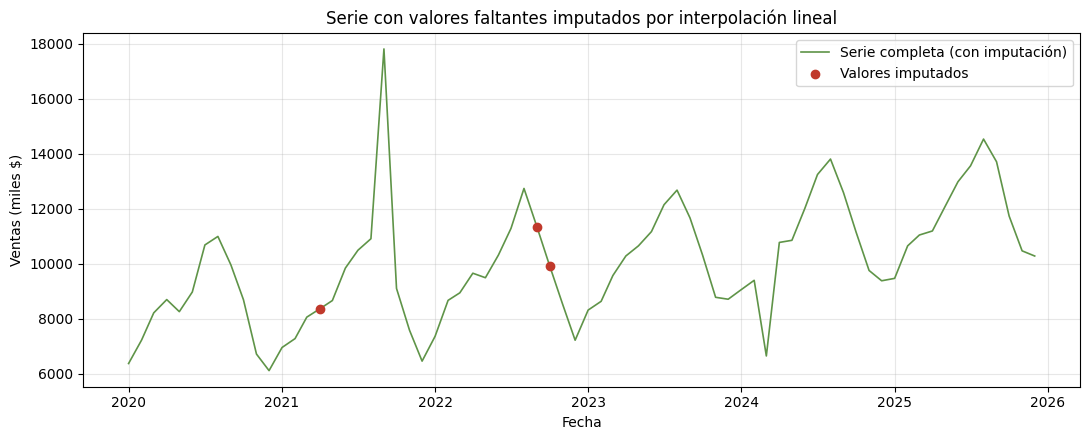

In [10]:
df['ventas_imputado'] = df['ventas'].interpolate(method='linear')

# Verificamos que ya no queden nulos
print("Valores nulos después de interpolar:", df['ventas_imputado'].isna().sum())

# Visualizamos donde se imputaron los valores
fig, ax = plt.subplots()
ax.plot(df.index, df['ventas_imputado'], color='#5F9448', label='Serie completa (con imputación)', linewidth=1.2)
ax.scatter(faltantes.index, df.loc[faltantes.index, 'ventas_imputado'], color='#C0392B', zorder=5, label='Valores imputados')
ax.set_title("Serie con valores faltantes imputados por interpolación lineal")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.5 Revisar valores atípicos (outliers)

Como la serie tiene tendencia y estacionalidad, comparar los valores absolutos entre sí no es suficiente (un mes de temporada alta es naturalmente más alto que uno de temporada baja, y eso no lo hace un outlier). Por eso, calculamos el **residuo** respecto a una media móvil centrada y marcamos como atípico cualquier punto cuyo residuo se aleje más de 2.5 desviaciones estándar del promedio de los residuos.

In [11]:
media_movil = df['ventas_imputado'].rolling(window=5, center=True).mean()
residuo = df['ventas_imputado'] - media_movil

umbral = 2.2 * residuo.std()
atipicos = df[(residuo.abs() > umbral)]

print(f"Cantidad de valores atípicos detectados: {len(atipicos)}")
atipicos[['ventas_imputado']]

Cantidad de valores atípicos detectados: 2


,ventas_imputado
fecha,
2021-09-01,17819.0
2024-03-01,6649.0


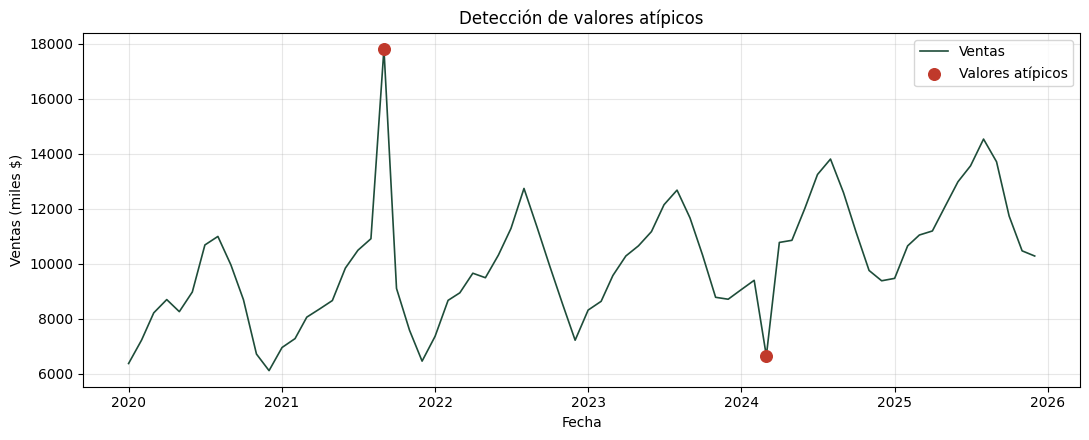

In [12]:
fig, ax = plt.subplots()
ax.plot(df.index, df['ventas_imputado'], color='#1F4D3A', linewidth=1.2, label='Ventas')
ax.scatter(atipicos.index, atipicos['ventas_imputado'], color='#C0392B', s=70, zorder=5, label='Valores atípicos')
ax.set_title("Detección de valores atípicos")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** se detectaron 2 valores atípicos:

- **Septiembre 2021:** un pico muy por encima de lo esperado para ese mes — podría explicarse por una promoción puntual o una compra grande de un cliente específico, no por un cambio estructural del negocio.
- **Marzo 2024:** una caída fuerte respecto a lo esperado — compatible con un quiebre de stock o un problema logístico puntual.

Como ambos son eventos puntuales y no representan un cambio de comportamiento del negocio (no se repiten en los meses siguientes), se decide **suavizarlos reemplazándolos por el valor de la media móvil local**, para que no distorsionen la estimación de tendencia y estacionalidad en los modelos. Se documenta la decisión y se conserva la serie original (`ventas`) sin modificar, por transparencia.

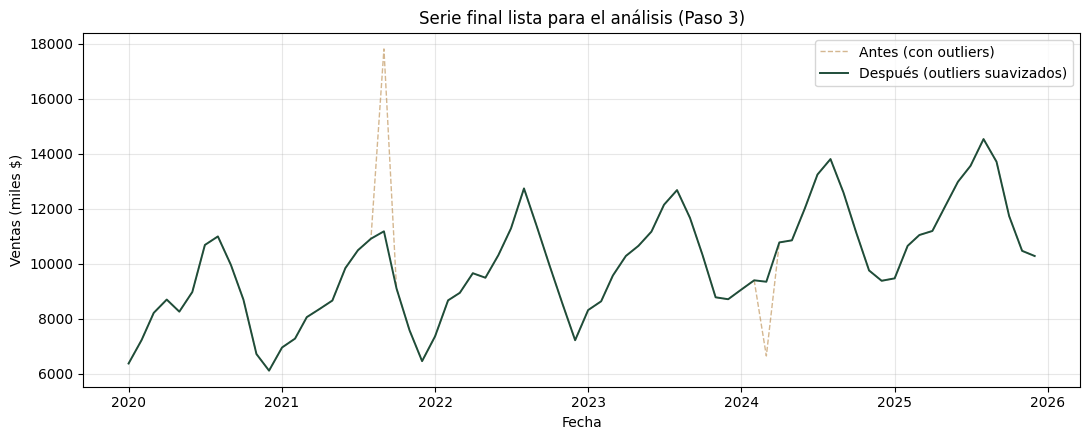

,ventas,ventas_final
fecha,,
2025-08-01,14539.0,14539.0
2025-09-01,13714.0,13714.0
2025-10-01,11741.0,11741.0
2025-11-01,10473.0,10473.0
2025-12-01,10285.0,10285.0


In [13]:
df['ventas_final'] = df['ventas_imputado'].copy()
df.loc[atipicos.index, 'ventas_final'] = media_movil.loc[atipicos.index]

fig, ax = plt.subplots()
ax.plot(df.index, df['ventas_imputado'], color='#B88746', linewidth=1, linestyle='--', alpha=0.6, label='Antes (con outliers)')
ax.plot(df.index, df['ventas_final'], color='#1F4D3A', linewidth=1.4, label='Después (outliers suavizados)')
ax.set_title("Serie final lista para el análisis (Paso 3)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

df[['ventas', 'ventas_final']].tail()

### Resumen del Paso 2

| Revisión | Resultado | Acción tomada |
|---|---|---|
| Fechas duplicadas | 1 (mayo 2023) | Se eliminó la fila repetida |
| Valores faltantes | 3 (abr-2021, sep-2022, oct-2022) | Interpolación lineal |
| Valores atípicos | 2 (sep-2021, feb-2024) | Suavizados con media móvil local |
| Frecuencia | Mensual (MS), 72 períodos | Definida explícitamente con `asfreq('MS')` |

La columna `ventas_final` es la que se usará en los pasos siguientes (análisis exploratorio, modelos y pronóstico).

## Paso 3: Análisis del comportamiento de la serie

### 3.1 Gráfico de la serie original

Trabajamos desde acá en adelante con la columna `ventas_final` (la serie ya limpia del Paso 2: sin duplicados, sin faltantes, sin los 2 valores atípicos puntuales).

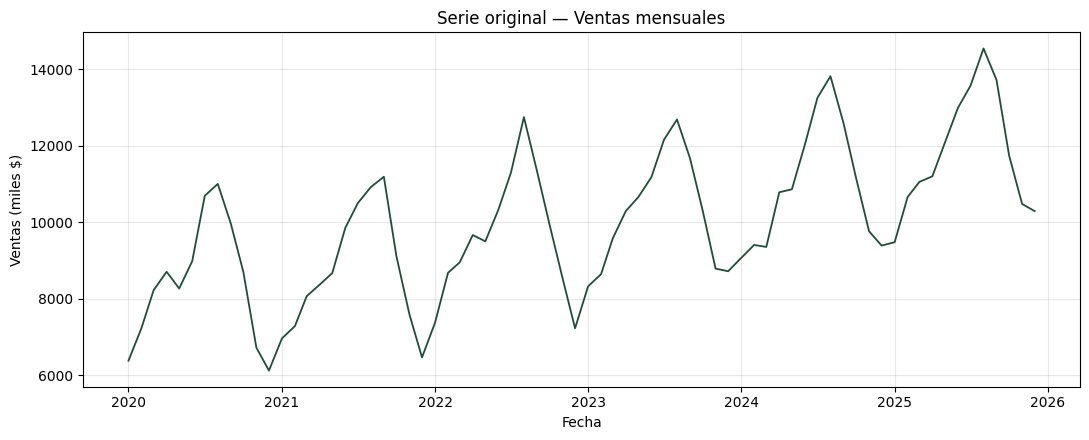

In [14]:
serie = df['ventas_final']

fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color='#1F4D3A', linewidth=1.3)
ax.set_title("Serie original — Ventas mensuales")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la serie muestra una tendencia claramente creciente a lo largo de los 6 años, con oscilaciones que se repiten cada 12 meses (picos hacia mitad de año y valles hacia fin/inicio de año). Esto sugiere presencia de **tendencia + estacionalidad anual**, algo típico de un negocio ligado a campañas agrícolas.

### 3.2 Análisis de tendencia

Para visualizar la tendencia de forma más limpia (sin el "ruido" de la estacionalidad), calculamos una **media móvil de 12 meses** (una ventana completa de un año), que suaviza el patrón estacional y deja ver la dirección de fondo de la serie.

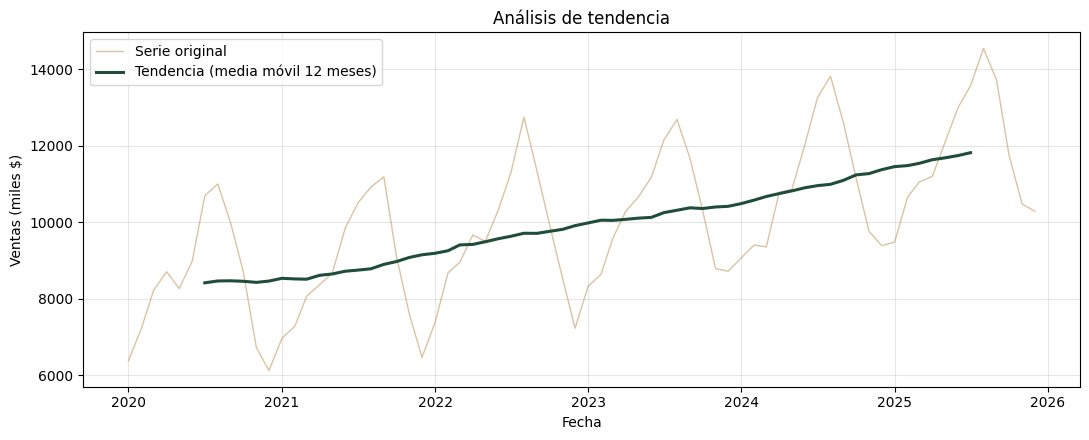

In [15]:
tendencia_mm12 = serie.rolling(window=12, center=True).mean()

fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color='#B88746', alpha=0.5, linewidth=1, label='Serie original')
ax.plot(tendencia_mm12.index, tendencia_mm12.values, color='#1F4D3A', linewidth=2.2, label='Tendencia (media móvil 12 meses)')
ax.set_title("Análisis de tendencia")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la línea de tendencia (verde) confirma un **crecimiento sostenido** durante todo el período, sin señales de estancamiento o caída estructural. El crecimiento parece acelerarse levemente hacia los últimos años.

### 3.3 Promedio móvil

Además de la media móvil de 12 meses (usada arriba para ver la tendencia), calculamos una de **3 meses**, que suaviza el ruido de corto plazo sin borrar del todo la estacionalidad — útil para ver la "forma" de la serie con menos oscilación mes a mes.

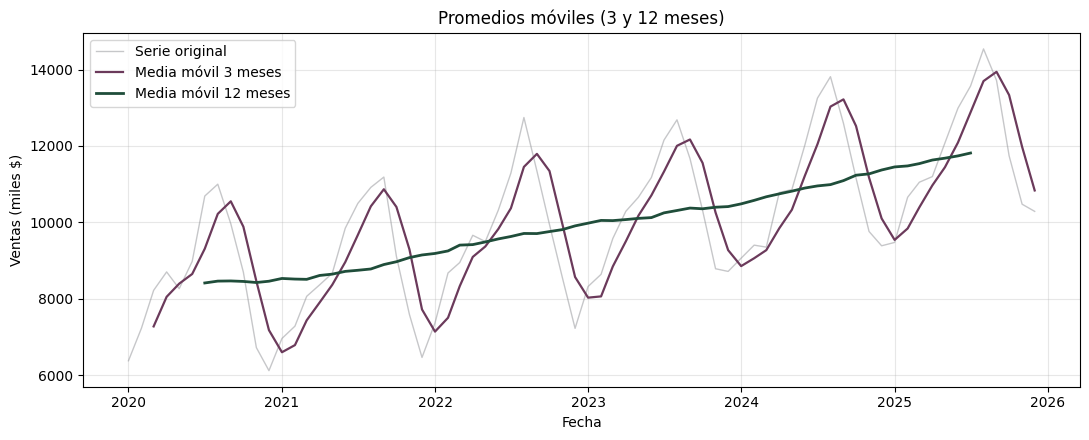

In [16]:
mm3 = serie.rolling(window=3).mean()

fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color='#8F9095', alpha=0.5, linewidth=1, label='Serie original')
ax.plot(mm3.index, mm3.values, color='#6B3A5B', linewidth=1.6, label='Media móvil 3 meses')
ax.plot(tendencia_mm12.index, tendencia_mm12.values, color='#1F4D3A', linewidth=2, label='Media móvil 12 meses')
ax.set_title("Promedios móviles (3 y 12 meses)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura del gráfico:** la media móvil de 3 meses conserva algo de la forma estacional (todavía sube y baja dentro del año), mientras que la de 12 meses la elimina casi por completo, dejando ver solo la tendencia de fondo. Esto confirma que la estacionalidad de esta serie tiene un ciclo de 12 meses.

### 3.4 Análisis de estacionalidad

Para confirmar el patrón estacional, agrupamos las ventas por mes calendario (independiente del año) y las comparamos con un boxplot — así vemos si ciertos meses son sistemáticamente más altos o más bajos que otros.

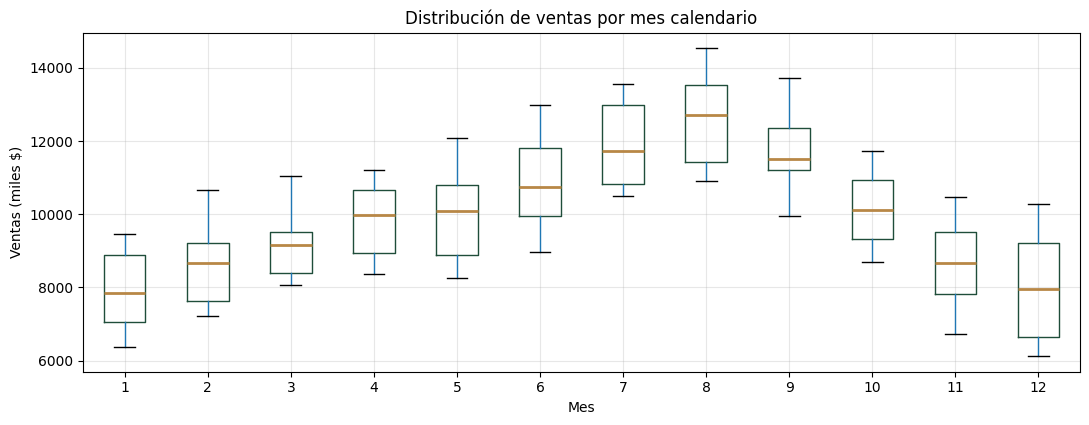

In [17]:
df_mes = serie.reset_index()
df_mes['mes'] = df_mes['fecha'].dt.month

fig, ax = plt.subplots(figsize=(11,4.5))
df_mes.boxplot(column='ventas_final', by='mes', ax=ax,
               boxprops=dict(color='#1F4D3A'), medianprops=dict(color='#B88746', linewidth=2))
ax.set_title("Distribución de ventas por mes calendario")
ax.set_xlabel("Mes"); ax.set_ylabel("Ventas (USD)")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Lectura del gráfico:** se confirma un patrón estacional claro — los meses centrales del año (aprox. junio a septiembre, temporada de aplicación en campo) muestran ventas sistemáticamente más altas, mientras que los meses de fin/inicio de año (noviembre a febrero) son los más bajos. Este patrón se repite todos los años, por lo que es **estacionalidad real**, no ruido aleatorio.

### 3.5 Descomposición de la serie

Separamos formalmente la serie en sus 3 componentes: **tendencia**, **estacionalidad** y **residuo** (lo que no explican las dos anteriores). Usamos descomposición **aditiva**, ya que la amplitud de las oscilaciones estacionales se mantiene relativamente constante a lo largo del tiempo (no crece proporcionalmente al nivel de la serie, que sería el caso para usar descomposición multiplicativa).

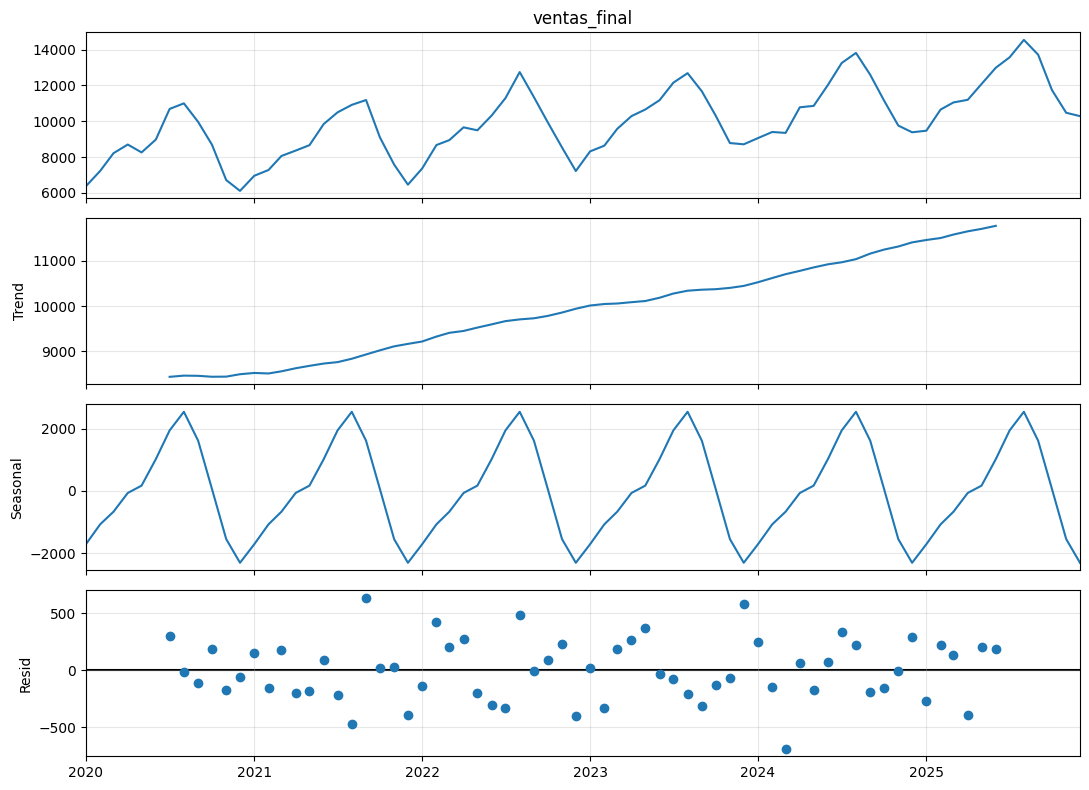

In [18]:
descomposicion = seasonal_decompose(serie, model='additive', period=12)

fig = descomposicion.plot()
fig.set_size_inches(11, 8)
for ax in fig.axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura de la descomposición:**
- **Trend:** confirma la tendencia creciente ya identificada.
- **Seasonal:** muestra un patrón que se repite idéntico cada 12 meses, con amplitud aproximada de ±2.500 respecto al nivel central.
- **Resid:** los residuos se mueven sin un patrón claro alrededor de cero, lo cual es buena señal — indica que la tendencia y la estacionalidad ya capturan la mayor parte del comportamiento de la serie, y lo que queda es más cercano a ruido.

### 3.6 ACF y PACF

La **ACF** (autocorrelación) y la **PACF** (autocorrelación parcial) muestran qué tan relacionado está cada valor con sus valores pasados (rezagos). Estas gráficas son la principal pista para elegir los parámetros de los modelos ARIMA/SARIMA más adelante.

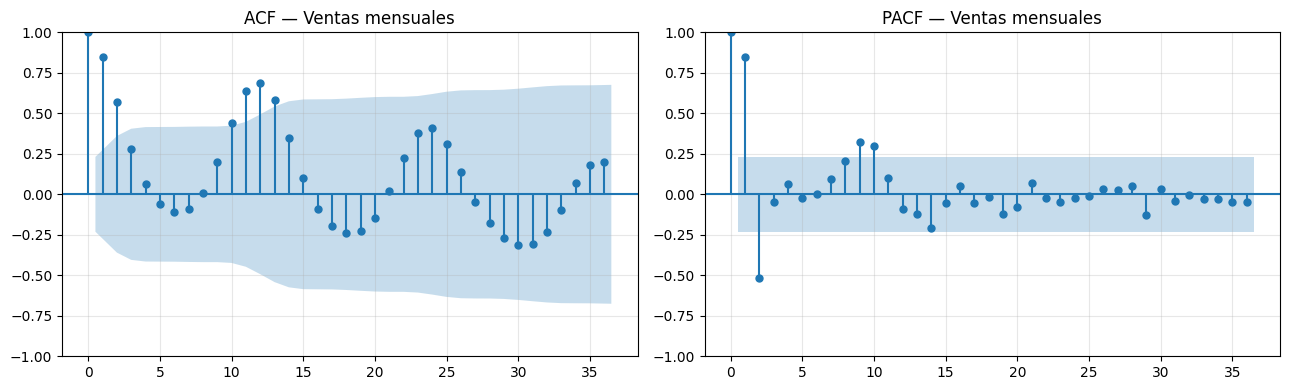

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
plot_acf(serie, lags=36, ax=axes[0])
axes[0].set_title("ACF — Ventas mensuales")
plot_pacf(serie, lags=36, ax=axes[1], method='ywm')
axes[1].set_title("PACF — Ventas mensuales")
plt.tight_layout()
plt.show()

**Lectura de ACF/PACF:**
- La **ACF** decae muy lentamente y muestra picos marcados cada 12 rezagos — típico de una serie con tendencia (decaimiento lento) y estacionalidad de período 12 (picos periódicos). Esto es evidencia adicional de que la serie **no es estacionaria** en su forma original.
- La **PACF** muestra una caída abrupta después del primer rezago, con un repunte notorio también en el rezago 12 — esto sugiere que un componente autorregresivo simple (AR) más un componente estacional (con período 12) tienen sentido para el modelo ARIMA/SARIMA que construiremos más adelante.

### 3.7 Prueba de estacionariedad (ADF)

La prueba **Augmented Dickey-Fuller** contrasta formalmente si la serie es estacionaria:

- **H0 (hipótesis nula):** la serie NO es estacionaria (tiene raíz unitaria).
- **H1 (alternativa):** la serie SÍ es estacionaria.

Si el p-valor es menor a 0.05, rechazamos H0 y concluimos que la serie es estacionaria.

In [20]:
resultado_adf = adfuller(serie)

print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.4f}")
print("Valores críticos:")
for k, v in resultado_adf[4].items():
    print(f"   {k}: {v:.4f}")

if resultado_adf[1] < 0.05:
    print("\n→ Se rechaza H0: la serie ES estacionaria.")
else:
    print("\n→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación).")

Estadístico ADF: 1.6011
p-valor: 0.9979
Valores críticos:
   1%: -3.5464
   5%: -2.9119
   10%: -2.5937

→ No se rechaza H0: la serie NO es estacionaria (requiere diferenciación).


**Interpretación:** dado el p-valor obtenido, no podemos rechazar la hipótesis nula → la serie **no es estacionaria**, tal como ya sugerían el gráfico original (tendencia visible) y la ACF (decaimiento lento). Esto confirma que se necesitará **diferenciación** antes de aplicar ARIMA (y diferenciación estacional de orden 12 para SARIMA).

### Probamos con la serie diferenciada

Aplicamos una diferenciación regular (orden 1) y volvemos a correr la prueba ADF, para confirmar que con eso alcanza para lograr estacionariedad.

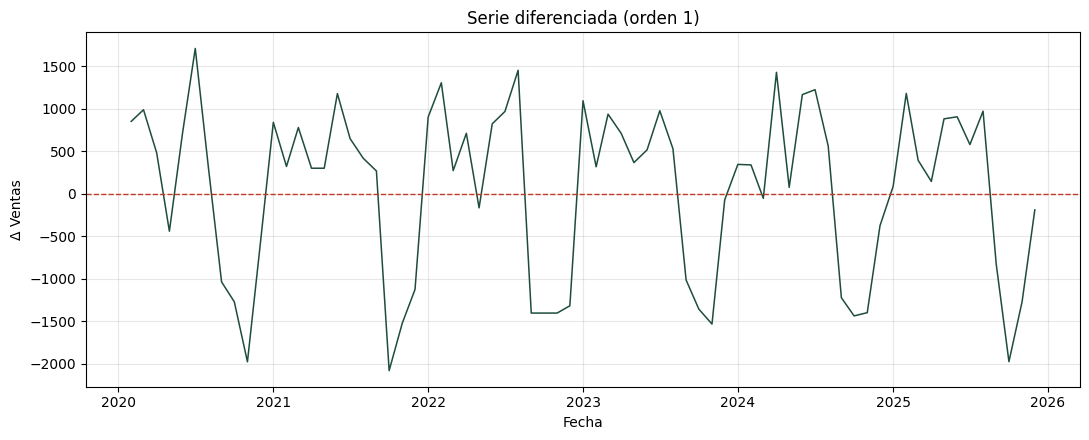

p-valor (serie diferenciada): 0.0000
→ Con una diferenciación (d=1), la serie SÍ se vuelve estacionaria.


In [21]:
serie_diff = serie.diff().dropna()

fig, ax = plt.subplots()
ax.plot(serie_diff.index, serie_diff.values, color='#1F4D3A', linewidth=1.1)
ax.axhline(0, color='#C0392B', linewidth=1, linestyle='--')
ax.set_title("Serie diferenciada (orden 1)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Δ Ventas")
plt.tight_layout()
plt.show()

resultado_adf_diff = adfuller(serie_diff)
print(f"p-valor (serie diferenciada): {resultado_adf_diff[1]:.4f}")
if resultado_adf_diff[1] < 0.05:
    print("→ Con una diferenciación (d=1), la serie SÍ se vuelve estacionaria.")
else:
    print("→ Aún no es estacionaria, podría necesitar una diferenciación adicional o estacional.")

### Resumen del Paso 3

| Pregunta | Respuesta |
|---|---|
| ¿La serie sube, baja o se mantiene estable? | **Sube** — tendencia creciente sostenida durante los 6 años |
| ¿Tiene patrones repetitivos? | **Sí** — estacionalidad anual clara (alta en meses centrales del año, baja en extremos) |
| ¿Parece estacionaria? | **No** — confirmado por el gráfico, la ACF y la prueba ADF (p-valor > 0.05) |
| ¿Necesita diferenciación? | **Sí** — con d=1 (diferenciación regular) se logra estacionariedad; para SARIMA también se usará diferenciación estacional (D=1, período 12) |
| ¿Qué pistas dan ACF y PACF para modelar? | PACF sugiere un componente AR simple + estacional en el rezago 12 → apunta a un modelo **SARIMA** más que un ARIMA simple, dado el fuerte patrón estacional |


## Paso 4: Separar entrenamiento y prueba

En series de tiempo **no se puede dividir al azar** como en otros problemas de machine learning. La razón es simple: si mezclamos datos del futuro dentro del entrenamiento, el modelo estaría "haciendo trampa" — aprendería con información que en la vida real todavía no existiría al momento de pronosticar. A esto se le llama *fuga de información (data leakage)*.

La regla siempre es: **se entrena con el pasado y se evalúa con el futuro**, respetando el orden cronológico.

**Elección de la división:** usamos los **últimos 12 meses como conjunto de prueba** (en vez de un porcentaje como 80/20). Elegimos 12 meses porque:
- Coincide con un ciclo estacional completo (podemos evaluar si el modelo captura bien los 12 meses del patrón, no solo una parte).
- Es un horizonte realista para el negocio: es razonable que quieran pronósticos con 6-12 meses de anticipación (ver Paso 7).

In [23]:
n_test = 12
train = serie.iloc[:-n_test]
test = serie.iloc[-n_test:]

print(f"Entrenamiento: {len(train)} meses  ({train.index.min().strftime('%Y-%m')} a {train.index.max().strftime('%Y-%m')})")
print(f"Prueba:        {len(test)} meses  ({test.index.min().strftime('%Y-%m')} a {test.index.max().strftime('%Y-%m')})")

Entrenamiento: 60 meses  (2020-01 a 2024-12)
Prueba:        12 meses  (2025-01 a 2025-12)


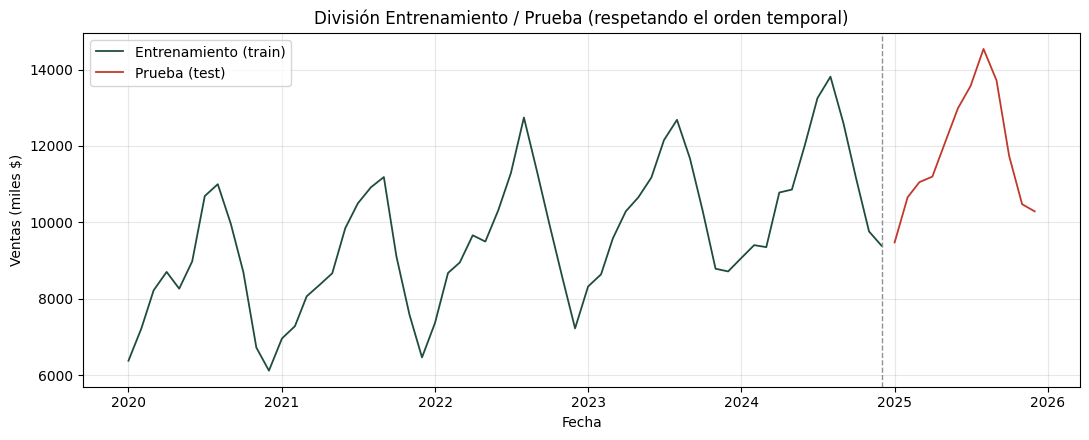

In [24]:
fig, ax = plt.subplots()
ax.plot(train.index, train.values, color='#1F4D3A', linewidth=1.3, label='Entrenamiento (train)')
ax.plot(test.index, test.values, color='#C0392B', linewidth=1.3, label='Prueba (test)')
ax.axvline(train.index[-1], color='#8F9095', linestyle='--', linewidth=1)
ax.set_title("División Entrenamiento / Prueba (respetando el orden temporal)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Cómo se va a usar esta división en los pasos siguientes:**

- Todos los modelos (Paso 5) se van a **entrenar únicamente con `train`** (60 meses, enero 2020 a diciembre 2024).
- Después, cada modelo va a generar un pronóstico para esos mismos 12 meses de `test`, y vamos a comparar ese pronóstico contra los valores reales de `test` para calcular las métricas de error (Paso 6).
- Recién en el Paso 7, una vez elegido el mejor modelo, lo vamos a re-entrenar con **todos los datos** (train + test) para generar el pronóstico real hacia el futuro (meses que todavía no existen).

## Paso 5: Construir y comparar modelos

Vamos a entrenar 4 modelos, cada uno **solo con `train`**, y vamos a generar el pronóstico de los 12 meses de `test` con cada uno. Los resultados se guardan en un diccionario para compararlos todos juntos en el Paso 6.

In [25]:
pronosticos = {}   # aca guardamos el pronostico de cada modelo para los 12 meses de test
modelos_info = {}  # aca guardamos AIC/BIC cuando aplique

### 5.1 Modelo Benchmark — Seasonal Naive

El benchmark tiene que ser un modelo **simple**, que sirva de piso mínimo de comparación. Elegimos **seasonal naive** (en vez de solo repetir el último valor) porque la serie tiene una estacionalidad muy marcada — un naive simple (repetir el último valor de train para los 12 meses) ignoraría por completo ese patrón y sería una comparación injusta.

La regla de seasonal naive es: *el pronóstico para cada mes es igual al valor de ese mismo mes, un año atrás.*

In [25]:
pronostico_benchmark = train.iloc[-12:].copy()
pronostico_benchmark.index = test.index  # alineamos las fechas con el periodo de test

pronosticos['Benchmark (Seasonal Naive)'] = pronostico_benchmark
print(pronostico_benchmark)

fecha
2025-01-01     9060.0
2025-02-01     9401.0
2025-03-01     9349.0
2025-04-01    10779.0
2025-05-01    10856.0
2025-06-01    12024.0
2025-07-01    13250.0
2025-08-01    13812.0
2025-09-01    12591.0
2025-10-01    11156.0
2025-11-01     9759.0
2025-12-01     9384.0
Freq: MS, Name: ventas_final, dtype: float64


### 5.2 Suavizado Exponencial — Holt-Winters

Usamos **Holt-Winters con tendencia y estacionalidad aditivas**, ya que en el Paso 3 vimos que:
- Hay tendencia clara (componente *Holt*).
- Hay estacionalidad de período 12 con amplitud aproximadamente constante (componente estacional *aditivo*, no multiplicativo).

In [26]:
modelo_hw = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit()

pronostico_hw = modelo_hw.forecast(12)
pronostico_hw.index = test.index

pronosticos['Holt-Winters'] = pronostico_hw
print(pronostico_hw)

fecha
2025-01-01     9666.313706
2025-02-01    10294.994056
2025-03-01    10881.103611
2025-04-01    11609.008437
2025-05-01    11637.708022
2025-06-01    12518.684785
2025-07-01    13625.937581
2025-08-01    14281.070592
2025-09-01    13400.888534
2025-10-01    11893.199850
2025-11-01    10328.107863
2025-12-01     9630.332501
Freq: MS, dtype: float64


### 5.3 ARIMA

Para elegir los parámetros (p, d, q) usamos `auto_arima`, que prueba distintas combinaciones y se queda con la que minimiza el AIC (en vez de probar a mano). Ya sabemos del Paso 3 que se necesita **d=1** (una diferenciación), así que el resultado debería confirmar eso.

Este ARIMA **no** incluye componente estacional — es intencional, para poder comparar en el Paso 6 qué tanto aporta realmente modelar la estacionalidad explícitamente (que es justo lo que hace el SARIMA de la siguiente sección).

In [27]:
import pmdarima as pm

auto_arima_modelo = pm.auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)
print(auto_arima_modelo.summary())

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=986.728, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=971.004, Time=0.02 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=972.608, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=984.881, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=971.055, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=972.206, Time=0.02 sec


 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=959.563, Time=0.13 sec


 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=960.598, Time=0.18 sec


...

 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=951.560, Time=0.19 sec


 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=962.103, Time=0.20 sec


 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec


 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=960.259, Time=0.23 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=970.508, Time=0.06 sec


 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(3,1,2)(0,0,0)[0]             : AIC=964.825, Time=0.12 sec

Best model:  ARIMA(3,1,2)(0,0,0)[0] intercept
Total fit time: 1.975 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   60
Model:               SARIMAX(3, 1, 2)   Log Likelihood                -468.780
Date:                Wed, 08 Jul 2026   AIC                            951.560
Time:                        04:39:28   BIC                            966.102
Sample:                    01-01-2020   HQIC                           957.237
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
interce

In [28]:
orden_arima = auto_arima_modelo.order
print("Orden (p,d,q) elegido:", orden_arima)

modelo_arima = ARIMA(train, order=orden_arima).fit()

pronostico_arima = modelo_arima.forecast(12)
pronostico_arima.index = test.index

pronosticos['ARIMA'] = pronostico_arima
modelos_info['ARIMA'] = {'AIC': modelo_arima.aic, 'BIC': modelo_arima.bic}

print(pronostico_arima)
print(f"\nAIC: {modelo_arima.aic:.2f}   BIC: {modelo_arima.bic:.2f}")

Orden (p,d,q) elegido: (3, 1, 2)


fecha
2025-01-01     9473.840711
2025-02-01     9923.215377
2025-03-01    10453.377277
2025-04-01    10894.896681
2025-05-01    11146.753885
2025-06-01    11201.748241
2025-07-01    11109.858233
2025-08-01    10947.200838
2025-09-01    10784.362580
2025-10-01    10668.297152
2025-11-01    10616.644178
2025-12-01    10622.574591
Freq: MS, Name: predicted_mean, dtype: float64

AIC: 964.83   BIC: 977.29


### 5.4 SARIMA

Ahora sí incorporamos el componente estacional (P, D, Q, s=12), que en el Paso 3 vimos que era necesario (pico marcado en la ACF/PACF en el rezago 12). Usamos `auto_arima` nuevamente, esta vez con `seasonal=True` y `m=12`.

In [29]:
auto_sarima_modelo = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)
print(auto_sarima_modelo.summary())

Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=723.097, Time=0.65 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=732.465, Time=0.01 sec


 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=716.405, Time=0.24 sec


 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=717.355, Time=0.24 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=779.331, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=733.523, Time=0.02 sec


 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=718.134, Time=0.55 sec


...

 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=716.089, Time=0.40 sec


 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=718.634, Time=0.27 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=715.391, Time=0.13 sec


 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=717.939, Time=0.38 sec


 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=716.403, Time=0.23 sec


 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=716.389, Time=0.25 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=774.873, Time=0.03 sec

Best model:  ARIMA(0,0,0)(1,1,0)[12] intercept
Total fit time: 4.630 seconds
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Observations:                   60
Model:             SARIMAX(1, 1, 0, 12)   Log Likelihood                -354.205
Date:                  Wed, 08 Jul 2026   AIC                            714.411
Time:                          04:39:33   BIC                            720.024
Sample:                      01-01-2020   HQIC                           716.532
                           - 12-01-2024                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

In [30]:
orden_sarima = auto_sarima_modelo.order
orden_estacional_sarima = auto_sarima_modelo.seasonal_order
print("Orden (p,d,q):", orden_sarima)
print("Orden estacional (P,D,Q,s):", orden_estacional_sarima)

modelo_sarima = sm.tsa.SARIMAX(
    train, order=orden_sarima, seasonal_order=orden_estacional_sarima,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

pronostico_sarima = modelo_sarima.forecast(12)
pronostico_sarima.index = test.index

pronosticos['SARIMA'] = pronostico_sarima
modelos_info['SARIMA'] = {'AIC': modelo_sarima.aic, 'BIC': modelo_sarima.bic}

print(pronostico_sarima)
print(f"\nAIC: {modelo_sarima.aic:.2f}   BIC: {modelo_sarima.bic:.2f}")

Orden (p,d,q): (0, 0, 0)
Orden estacional (P,D,Q,s): (1, 1, 0, 12)
fecha
2025-01-01     9443.594881
2025-02-01     9795.968314
2025-03-01     9232.163823
2025-04-01    11033.351323
2025-05-01    10959.911821
2025-06-01    12463.945072
2025-07-01    13818.154682
2025-08-01    14396.180883
2025-09-01    13067.650243
2025-10-01    11591.292304
2025-11-01    10263.566851
2025-12-01     9730.889710
Freq: MS, Name: predicted_mean, dtype: float64

AIC: 582.88   BIC: 586.05


### 5.5 Comparación visual de los 4 pronósticos contra los valores reales de test

Antes de calcular las métricas formales (Paso 6), veamos gráficamente qué tan cerca queda cada modelo de los valores reales.

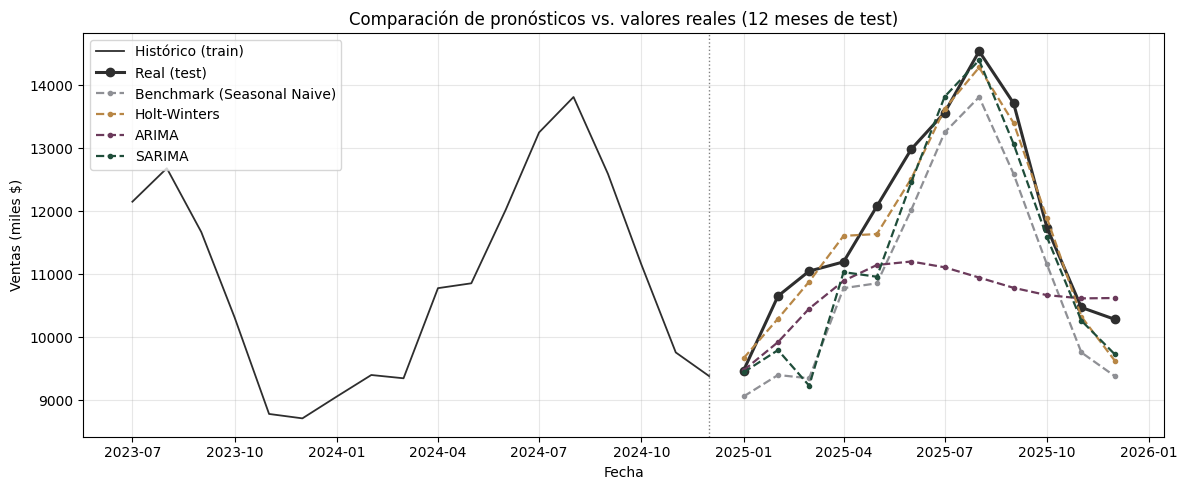

In [31]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index[-18:], train.values[-18:], color='#2E2E2E', linewidth=1.3, label='Histórico (train)')
ax.plot(test.index, test.values, color='#2E2E2E', linewidth=2.2, marker='o', label='Real (test)')

colores = {'Benchmark (Seasonal Naive)': '#8F9095', 'Holt-Winters': '#B88746',
           'ARIMA': '#6B3A5B', 'SARIMA': '#1F4D3A'}
for nombre, pron in pronosticos.items():
    ax.plot(pron.index, pron.values, linewidth=1.6, linestyle='--', marker='.',
            color=colores.get(nombre), label=nombre)

ax.axvline(train.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title("Comparación de pronósticos vs. valores reales (12 meses de test)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 Modelo adicional (opcional) — LightGBM con rezagos

A diferencia de los anteriores (modelos estadísticos clásicos), este es un modelo de **Machine Learning**. En vez de asumir una fórmula matemática fija (como ARIMA/SARIMA), aprende patrones a partir de variables (*features*) que nosotros construimos:

- **Rezagos (lags):** el valor de ventas de 1, 2, 3 y 12 meses atrás.
- **Mes del año**, codificado de forma cíclica (`seno`/`coseno`) para que el modelo entienda que diciembre y enero están "cerca" en el calendario.

**Importante — cómo se genera el pronóstico:** como el modelo necesita el valor del mes anterior para predecir el siguiente, no podemos predecir los 12 meses de una sola vez. Se hace de forma **recursiva**: se predice el mes 1, ese valor predicho se usa como insumo (rezago) para predecir el mes 2, y así sucesivamente. Esto es realista (así se usaría en producción) pero también significa que el error se puede ir acumulando mes a mes.

In [32]:
from lightgbm import LGBMRegressor

def crear_features(s, lags=(1,2,3,12)):
    df_feat = pd.DataFrame({'y': s})
    for lag in lags:
        df_feat[f'lag_{lag}'] = s.shift(lag)
    df_feat['mes'] = s.index.month
    df_feat['mes_sin'] = np.sin(2*np.pi*df_feat['mes']/12)
    df_feat['mes_cos'] = np.cos(2*np.pi*df_feat['mes']/12)
    return df_feat

LAGS = (1, 2, 3, 12)

feat_train = crear_features(train, LAGS).dropna()
X_train = feat_train.drop(columns='y')
y_train = feat_train['y']

print(f"Filas disponibles para entrenar (tras generar rezagos): {len(X_train)}")
X_train.head()

Filas disponibles para entrenar (tras generar rezagos): 48


,lag_1,lag_2,lag_3,lag_12,mes,mes_sin,mes_cos
fecha,,,,,,,
2021-01-01,6115.0,6718.0,8693.0,6374.0,1,0.500000,8.660254e-01
2021-02-01,6957.0,6115.0,6718.0,7227.0,2,0.866025,5.000000e-01
2021-03-01,7280.0,6957.0,6115.0,8217.0,3,1.000000,6.123234e-17
2021-04-01,8061.0,7280.0,6957.0,8700.0,4,0.866025,-5.000000e-01
2021-05-01,8363.0,8061.0,7280.0,8261.0,5,0.500000,-8.660254e-01


In [33]:
modelo_lgb = LGBMRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    min_child_samples=5, random_state=42, verbose=-1
)
modelo_lgb.fit(X_train, y_train)

# Pronostico recursivo mes a mes
historial = train.copy()
predicciones = []

for fecha in test.index:
    fila = {f'lag_{lag}': historial.iloc[-lag] for lag in LAGS}
    fila['mes'] = fecha.month
    fila['mes_sin'] = np.sin(2*np.pi*fecha.month/12)
    fila['mes_cos'] = np.cos(2*np.pi*fecha.month/12)
    X_pred = pd.DataFrame([fila])[X_train.columns]

    pred = modelo_lgb.predict(X_pred)[0]
    predicciones.append(pred)
    historial.loc[fecha] = pred  # se agrega para poder calcular los rezagos del siguiente mes

pronostico_lgb = pd.Series(predicciones, index=test.index)
pronosticos['LightGBM (rezagos)'] = pronostico_lgb
print(pronostico_lgb)

fecha
2025-01-01     9841.460167
2025-02-01     9950.340875
2025-03-01     9885.707547
2025-04-01    11120.876133
2025-05-01    11941.330347
2025-06-01    12842.821143
2025-07-01    12971.517563
2025-08-01    13065.581334
2025-09-01    12209.035691
2025-10-01    11049.313745
2025-11-01     9917.470415
2025-12-01     9681.175727
Freq: MS, dtype: float64


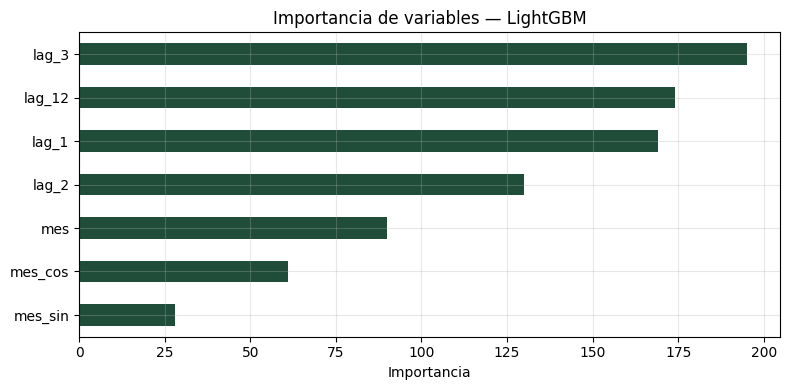

In [34]:
importancias = pd.Series(modelo_lgb.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8,4))
importancias.plot(kind='barh', ax=ax, color='#1F4D3A')
ax.set_title("Importancia de variables — LightGBM")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

**Lectura:** se espera que `lag_12` (el valor de hace un año) sea de las variables más importantes, ya que captura directamente la estacionalidad — de forma parecida a como el componente estacional de SARIMA also se apoya fuertemente en el rezago 12.

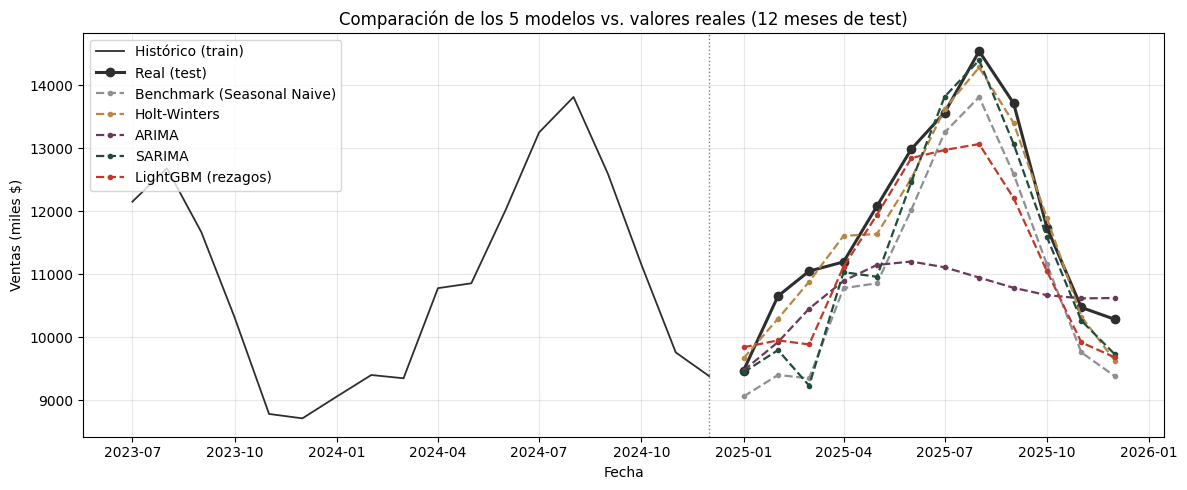

In [35]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index[-18:], train.values[-18:], color='#2E2E2E', linewidth=1.3, label='Histórico (train)')
ax.plot(test.index, test.values, color='#2E2E2E', linewidth=2.2, marker='o', label='Real (test)')

colores = {'Benchmark (Seasonal Naive)': '#8F9095', 'Holt-Winters': '#B88746',
           'ARIMA': '#6B3A5B', 'SARIMA': '#1F4D3A', 'LightGBM (rezagos)': '#C0392B'}
for nombre, pron in pronosticos.items():
    ax.plot(pron.index, pron.values, linewidth=1.6, linestyle='--', marker='.',
            color=colores.get(nombre), label=nombre)

ax.axvline(train.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title("Comparación de los 5 modelos vs. valores reales (12 meses de test)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Paso 6: Evaluar los modelos

Calculamos las métricas obligatorias para los 5 modelos, comparando el pronóstico de cada uno contra los valores **reales** de `test` (nunca contra los mismos datos de entrenamiento — eso invalidaría la evaluación).

- **MAE** (Error Absoluto Medio): el error promedio, en las mismas unidades que las ventas (USD). Fácil de interpretar.
- **MSE** (Error Cuadrático Medio): penaliza más fuerte los errores grandes.
- **RMSE**: raíz del MSE, vuelve a las unidades originales.
- **MAPE**: error porcentual promedio — útil para comparar aunque cambiara la escala del negocio.
- **AIC / BIC**: solo aplican a ARIMA y SARIMA (miden qué tan bien el modelo se ajusta penalizando la complejidad; no aplican a Holt-Winters, benchmark o LightGBM porque no se estiman por máxima verosimilitud de la misma forma).

In [36]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return mae, mse, rmse, mape

resultados = []
for nombre, pron in pronosticos.items():
    mae, mse, rmse, mape = calcular_metricas(test.values, pron.values)
    aic = modelos_info.get(nombre, {}).get('AIC', "No aplica")
    bic = modelos_info.get(nombre, {}).get('BIC', "No aplica")
    resultados.append({
        'Modelo': nombre, 'MAE': round(mae,1), 'MSE': round(mse,1),
        'RMSE': round(rmse,1), 'MAPE (%)': round(mape,2),
        'AIC': round(aic,1) if isinstance(aic,(int,float)) else aic,
        'BIC': round(bic,1) if isinstance(bic,(int,float)) else bic,
    })

tabla_resultados = pd.DataFrame(resultados).sort_values('RMSE').reset_index(drop=True)
tabla_resultados

,Modelo,MAE,MSE,RMSE,MAPE (%),AIC,BIC
0,Holt-Winters,302.1,118286.4,343.9,2.62,No aplica,No aplica
1,SARIMA,538.5,538694.4,734.0,4.65,582.9,586.0
2,LightGBM (rezagos),668.0,664243.3,815.0,5.54,No aplica,No aplica
3,Benchmark (Seasonal Naive),861.1,898179.2,947.7,7.40,No aplica,No aplica
4,ARIMA,1239.8,2819485.6,1679.1,9.53,964.8,977.3


**Resultado llamativo:** aunque en el gráfico del Paso 5 el pronóstico de **SARIMA** parecía visualmente el que mejor seguía el pico de mitad de año, al calcular las métricas formales **Holt-Winters** resultó ser el modelo con menor error en las 4 métricas (MAE, MSE, RMSE y MAPE). Esto es un buen recordatorio de por qué no basta con "mirar el gráfico" — los números pueden contradecir la primera impresión visual.

Antes de decidir, revisemos más a fondo: ¿el error de cada modelo se mantiene estable a lo largo de los 12 meses, o se concentra en algunos puntos?

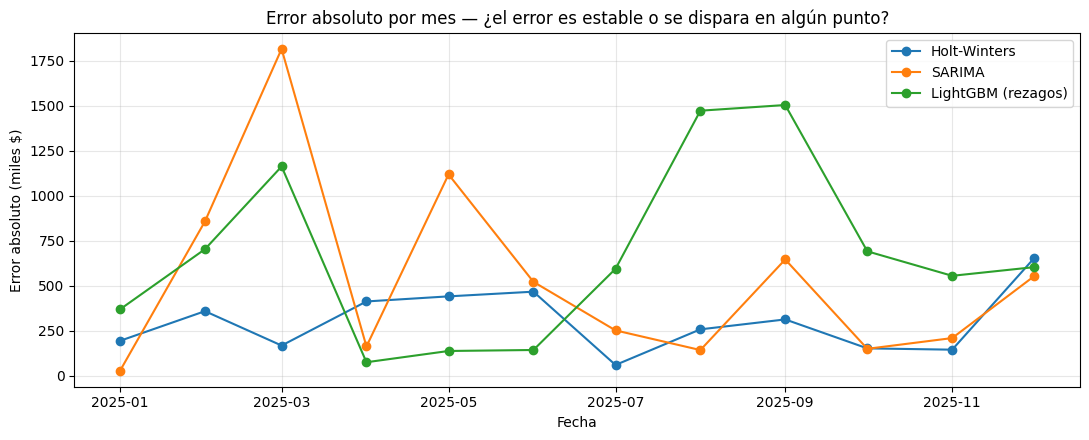

In [37]:
fig, ax = plt.subplots(figsize=(11,4.5))
for nombre in ['Holt-Winters', 'SARIMA', 'LightGBM (rezagos)']:
    error_abs = (pronosticos[nombre] - test).abs()
    ax.plot(error_abs.index, error_abs.values, marker='o', label=nombre)

ax.set_title("Error absoluto por mes — ¿el error es estable o se dispara en algún punto?")
ax.set_xlabel("Fecha"); ax.set_ylabel("Error absoluto (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura de este gráfico:** confirma lo que ya mostraban las métricas — el error de **Holt-Winters** (azul) se mantiene bajo y estable durante casi todo el horizonte de 12 meses, sin picos grandes. En cambio, **SARIMA** (naranjo) tiene errores muy altos en enero-marzo y mayo-junio, y **LightGBM** (verde) se dispara fuertemente entre julio y septiembre (justamente donde su pronóstico se quedó corto frente al pico real, como se vio en el gráfico del Paso 5).

### ¿Cuál modelo tuvo mejor desempeño y por qué?

Evaluando más allá de una sola métrica, como pide el enunciado:

| Criterio | Holt-Winters | SARIMA | LightGBM |
|---|---|---|---|
| **Captura la tendencia** | Sí, explícitamente (componente de nivel + tendencia) | Sí, vía diferenciación | Sí, a través de los rezagos |
| **Captura la estacionalidad** | Sí, explícitamente (componente estacional aditivo) | Sí, vía diferenciación estacional | Parcialmente (vía lag_12 y mes) |
| **Estabilidad del error** | **Alta** — error bajo y parejo en casi todo el horizonte | Baja — picos grandes en varios meses | Baja — se dispara en la temporada alta |
| **Interpretabilidad** | Alta — nivel, tendencia y estacionalidad son fáciles de explicar a negocio | Media — coeficientes AR/MA menos intuitivos | Baja — "caja gris", requiere explicar importancia de variables |
| **Sentido para el negocio** | Alto — modela exactamente la lógica del negocio (crecimiento + campañas estacionales) | Alto | Medio — necesitaría más datos históricos para aprovechar mejor su potencial |
| **MAE / RMSE / MAPE** | **Mejores de los 5 modelos** | Peores que Holt-Winters | Peores que Holt-Winters |

**Conclusión:** se selecciona **Holt-Winters** como el mejor modelo. No solo tuvo el menor error en las 4 métricas obligatorias, sino que además su error fue el más estable a lo largo del horizonte, y es el modelo más simple e interpretable de explicar a alguien del área comercial ("el nivel actual, más la tendencia de crecimiento, más el ajuste típico de cada mes del año").

Es un buen recordatorio de que **el modelo más sofisticado (SARIMA, o el de Machine Learning) no siempre es el que mejor funciona** — con una serie relativamente corta (60 meses de entrenamiento) y un patrón estacional muy regular, un modelo más simple como Holt-Winters puede generalizar mejor que uno con más parámetros para estimar.

## Paso 7: Pronóstico final

El modelo seleccionado en el Paso 6 fue **Holt-Winters**. Antes de generar el pronóstico real hacia el futuro, lo **re-entrenamos usando el 100% de los datos disponibles** (train + test, los 72 meses completos) — ya no tiene sentido reservar un conjunto de prueba, porque ya elegimos y validamos el modelo; usar toda la información histórica solo puede mejorar la calidad del pronóstico final.

**Horizonte elegido:** 12 meses (todo el año 2026), ya que la serie es mensual y un año completo permite ver el ciclo estacional completo en el pronóstico, útil para planificación anual de inventario y equipo comercial.

In [39]:
HORIZONTE = 12

modelo_final = ExponentialSmoothing(
    serie, trend='add', seasonal='add', seasonal_periods=12
).fit()

pronostico_final = modelo_final.forecast(HORIZONTE)

# Intervalo de confianza aproximado via simulacion (Holt-Winters no entrega IC analitico directo)
simulaciones = modelo_final.simulate(nsimulations=HORIZONTE, repetitions=1000, anchor='end', random_state=42)
ic_bajo = simulaciones.quantile(0.05, axis=1)
ic_alto = simulaciones.quantile(0.95, axis=1)

print(f"Pronóstico generado para: {pronostico_final.index.min().strftime('%Y-%m')} a {pronostico_final.index.max().strftime('%Y-%m')}")

Pronóstico generado para: 2026-01 a 2026-12


In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

plt.rcParams['animation.embed_limit'] = 50  # MB, margen para que la animacion quepa embebida

fig, ax = plt.subplots(figsize=(12, 5))

def actualizar(frame):
    ax.clear()
    ax.plot(serie.index, serie.values, color='#2E2E2E', linewidth=1.2, label='Historico (2020-2025)')

    # Revelamos el pronostico mes a mes, de a poco
    idx_hasta = frame + 1
    fechas_parciales = pronostico_final.index[:idx_hasta]
    valores_parciales = pronostico_final.values[:idx_hasta]
    ic_bajo_parcial = ic_bajo.values[:idx_hasta]
    ic_alto_parcial = ic_alto.values[:idx_hasta]

    ax.plot(fechas_parciales, valores_parciales, color='#1F4D3A', linewidth=2, marker='o', label='Pronostico 2026')
    ax.fill_between(fechas_parciales, ic_bajo_parcial, ic_alto_parcial, color='#5F9448', alpha=0.2, label='Intervalo de confianza 90%')
    ax.axvline(serie.index[-1], color='gray', linestyle=':', linewidth=1)

    mes_actual = fechas_parciales[-1].strftime('%Y-%m')
    ax.set_title(f"Pronostico final -- Ventas mensuales 2026 (modelo Holt-Winters)  |  Mostrando hasta: {mes_actual}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
    ax.set_xlim(serie.index.min(), pronostico_final.index.max())
    todos_valores = np.concatenate([serie.values, ic_alto.values])
    ax.set_ylim(min(serie.min(), ic_bajo.min()) * 0.95, todos_valores.max() * 1.05)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    fig.tight_layout()

anim = animation.FuncAnimation(fig, actualizar, frames=len(pronostico_final), interval=500, repeat=True)
plt.close()  # evita que ademas se muestre una figura estatica duplicada

HTML(anim.to_jshtml())


In [41]:
tabla_pronostico = pd.DataFrame({
    'Mes': pronostico_final.index.strftime('%Y-%m'),
    'Pronóstico': pronostico_final.values.round(0),
    'Límite inferior (5%)': ic_bajo.values.round(0),
    'Límite superior (95%)': ic_alto.values.round(0),
}).reset_index(drop=True)

tabla_pronostico

,Mes,Pronóstico,Límite inferior (5%),Límite superior (95%)
0,2026-01,10469.0,9937.0,11054.0
1,2026-02,11190.0,10638.0,11801.0
2,2026-03,11744.0,11191.0,12326.0
3,2026-04,12375.0,11769.0,12969.0
4,2026-05,12547.0,11910.0,13103.0
5,2026-06,13432.0,12803.0,14022.0
6,2026-07,14451.0,13855.0,15102.0
7,2026-08,15160.0,14519.0,15806.0
8,2026-09,14289.0,13683.0,14902.0
9,2026-10,12703.0,12077.0,13306.0


### Interpretación del pronóstico

El modelo proyecta que las ventas **continúan la tendencia creciente** durante 2026, alcanzando un pico estimado de **USD 15.160** en agosto de 2026 — un crecimiento de aproximadamente **4,3%** respecto al pico real de agosto 2025 (USD 14.539), consistente con la tasa de crecimiento observada en años anteriores.

El patrón estacional se mantiene igual que en los años históricos: ventas altas entre junio y septiembre (temporada de aplicación en campo), y más bajas entre noviembre y febrero.

### Limitaciones del resultado

- El intervalo de confianza (90%) se **amplía levemente a medida que avanza el horizonte**: en enero 2026 el rango es de ±560 respecto al pronóstico puntual, mientras que hacia diciembre 2026 ya es de ±650. Esto significa que los meses más lejanos del pronóstico deben tomarse con más cautela que los más cercanos.
- El modelo asume que el patrón de crecimiento y estacionalidad observado en 2020-2025 **se mantiene igual en 2026**. No incorpora información sobre factores externos que podrían cambiar ese patrón: nuevas regulaciones agrícolas, condiciones climáticas atípicas (sequías, heladas), cambios de precios de insumos, entrada de nuevos competidores, o crisis económicas.
- El pronóstico **no debe leerse como un valor exacto garantizado**, sino como el escenario más probable dado el comportamiento histórico — de ahí la importancia de mirarlo junto con su intervalo de confianza, y de monitorear mes a mes qué tan cerca se mantiene la realidad de lo proyectado.

## Paso 8: Conclusiones y recomendación

### ¿Qué modelo fue seleccionado?

Se seleccionó **Holt-Winters** (suavizado exponencial con tendencia y estacionalidad aditivas) como el modelo final, por sobre el Benchmark, ARIMA, SARIMA y LightGBM con rezagos.

### ¿Por qué se seleccionó ese modelo?

Porque fue el que mejor desempeño mostró considerando el panorama completo, no solo una métrica aislada:

- Tuvo el **menor error en las 4 métricas obligatorias** (MAE: 302, RMSE: 344, MAPE: 2,6%), muy por debajo del resto de los modelos, incluyendo SARIMA (RMSE: 734) y el modelo de Machine Learning (RMSE: 815).
- Su error se mantuvo **estable a lo largo de todo el horizonte de prueba**, sin picos grandes en meses puntuales — a diferencia de SARIMA y LightGBM, que tuvieron errores altos en varios meses.
- Es un modelo **simple e interpretable**: se explica con tres ideas (nivel actual, tendencia de crecimiento, ajuste típico de cada mes), fáciles de comunicar a alguien del área comercial sin formación técnica.
- Tiene **sentido para el negocio**: modela exactamente la lógica de la serie (crecimiento sostenido + campañas estacionales agrícolas), sin necesidad de una arquitectura más compleja.

Esto también deja una lección importante del proyecto: el modelo más sofisticado (SARIMA, o el de Machine Learning) no siempre es el que mejor generaliza — con una serie relativamente corta y un patrón estacional muy regular, un modelo más simple puede tener mejor desempeño real.

### ¿Qué comportamiento se espera en el futuro?

El modelo proyecta que las ventas **seguirán creciendo** durante 2026, manteniendo el mismo patrón estacional histórico: un pico hacia mitad de año (máximo estimado ~USD 15.160 en agosto 2026, ~4,3% más que el pico de 2025) y un valle hacia fin/inicio de año (~USD 10.500-11.200 entre noviembre 2026 y enero 2027).

### ¿Qué recomendación se puede dar?

Con base en estos resultados, se recomienda:

1. **Preparar inventario adicional** de cara a la temporada alta (junio-septiembre 2026), anticipando un crecimiento de aproximadamente 4-5% respecto al mismo período de 2025.
2. **Reforzar el equipo comercial y logístico** antes de junio, ya que el modelo anticipa que la demanda empieza a acelerarse con fuerza a partir de mayo.
3. **Planificar con más holgura los meses de noviembre a febrero**, donde se espera el nivel de ventas más bajo del año — buen momento para actividades de mantenimiento, capacitación de equipo o negociación de condiciones con proveedores.
4. **Monitorear mes a mes** el valor real contra el pronosticado, y prestar más atención si la desviación crece hacia el final del horizonte (donde el intervalo de confianza es más amplio).

### ¿Qué limitaciones tiene el análisis?

- El modelo se entrenó con **6 años de datos** (72 meses) — un historial más largo probablemente mejoraría la estimación del patrón estacional y de la tendencia.
- El pronóstico **asume que el futuro se comporta como el pasado**: no incorpora información sobre clima, competencia, regulación agrícola, precios internacionales de insumos, ni shocks económicos.
- Los dos valores atípicos identificados en el Paso 2 fueron suavizados asumiendo que eran eventos puntuales — si en realidad reflejaran un cambio estructural del negocio (por ejemplo, una promoción que se repetirá cada año), el modelo no lo estaría capturando.
- El resultado es una **proyección probable**, no una garantía — debe usarse como apoyo a la decisión, junto con el juicio del equipo comercial y el contexto real del negocio, no como una verdad absoluta.

## Extra: Backtesting interactivo (para portafolio)

Esta seccion no es parte de los 8 pasos pedidos por el profesor -- es un extra para mostrar el proyecto de forma mas visual e interactiva en GitHub/LinkedIn.

La idea del **backtesting walk-forward** es simular como se hubiera comportado el modelo "en produccion": en varios puntos del pasado, entrenamos el modelo solo con los datos disponibles hasta ese momento, generamos un pronostico de los siguientes 6 meses, y despues comparamos contra lo que realmente paso -- sin que el modelo haya "hecho trampa" viendo el futuro en ningun punto.

La animacion queda embebida directamente en el notebook con controles de **play/pausa, paso a paso y loop**, sin depender de ningun archivo externo (gif, video, etc.).

In [42]:
import matplotlib.animation as animation

VENTANA_INICIAL = 30   # meses minimos para el primer entrenamiento
HORIZONTE_BT = 6       # meses a pronosticar en cada punto
PASO_BT = 3            # cada cuantos meses avanza la animacion

origenes = list(range(VENTANA_INICIAL, len(serie) - HORIZONTE_BT, PASO_BT))

frames_data = []
for origen in origenes:
    train_bt = serie.iloc[:origen]
    real_futuro = serie.iloc[origen:origen + HORIZONTE_BT]
    modelo_bt = ExponentialSmoothing(train_bt, trend='add', seasonal='add', seasonal_periods=12).fit()
    pron_bt = modelo_bt.forecast(HORIZONTE_BT)
    frames_data.append((train_bt, real_futuro, pron_bt))

print(f"Animación con {len(frames_data)} frames (de {serie.index[VENTANA_INICIAL].strftime('%Y-%m')} en adelante)")

Animación con 12 frames (de 2022-07 en adelante)


In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

plt.rcParams['animation.embed_limit'] = 50  # MB, margen para que la animacion quepa embebida

fig, ax = plt.subplots(figsize=(10, 5))

def actualizar(i):
    ax.clear()
    train_bt, real_futuro, pron_bt = frames_data[i]
    ax.plot(train_bt.index, train_bt.values, color='#1F4D3A', linewidth=1.4, label='Datos originales (usados para entrenar)')
    ax.plot(real_futuro.index, real_futuro.values, color='#B88746', linewidth=2, marker='o', label='Datos nuevos (real, aun no visto)')
    ax.plot(pron_bt.index, pron_bt.values, color='#C0392B', linewidth=2, linestyle='--', marker='.', label='Pronostico del modelo')
    ax.set_title(f"Backtesting walk-forward -- Modelo Holt-Winters  |  Origen: {train_bt.index[-1].strftime('%Y-%m')}")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Ventas (USD)")
    ax.set_xlim(serie.index.min(), serie.index.max())
    ax.set_ylim(serie.min() * 0.9, serie.max() * 1.1)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    fig.tight_layout()

anim = animation.FuncAnimation(fig, actualizar, frames=len(frames_data), interval=800, repeat=True)
plt.close()  # evita que ademas se muestre una figura estatica duplicada

HTML(anim.to_jshtml())


**Lectura de la animacion:** en cada "origen" (punto en el tiempo), el modelo solo conoce los datos en verde oscuro. La linea roja punteada es lo que el modelo predijo para los siguientes 6 meses, y los puntos dorados son lo que realmente ocurrio. Usa los controles de abajo (play, pausa, paso a paso, loop) para recorrer la animacion. Ver que la linea roja se mantiene cerca de los puntos dorados en la mayoria de los "origenes" es una forma visual de confirmar la buena capacidad de generalizacion de Holt-Winters que ya haviamos visto en las metricas del Paso 6.